In [1]:
import numpy as np
import pandas as pd 

# Loading datasets

## Loading dataset with no filters applied

### Backend

In [2]:

backend_no_filter_df = pd.read_csv("metrics_no_filt/backend_metrics.csv")
backend_no_filter_df["Scenario"] = "No filter"
backend_no_filter_df = backend_no_filter_df.drop(columns=['RequestNo','StatusCode'])

In [3]:
backend_no_filter_df.head()

,Timestamp,API,LoadingType,Method,Endpoint,ResponseTime(ms),ResponseSize(Bytes),Scenario
0,2026-08-27T21:47:11.249Z,REST,Eager,POST,/fetchMovies,261.57,10173161,No filter
1,2026-08-27T21:48:34.474Z,REST,Eager,POST,/fetchMovies,291.54,10173161,No filter
2,2026-08-27T21:49:53.602Z,REST,Eager,POST,/fetchMovies,305.75,10173161,No filter
3,2026-08-27T21:51:08.329Z,REST,Eager,POST,/fetchMovies,298.52,10173161,No filter
4,2026-08-27T21:52:21.874Z,REST,Eager,POST,/fetchMovies,316.05,10173161,No filter


### Frontend

In [4]:
frontend_no_filter_df = pd.read_csv("metrics_no_filt/frontend_metrics.csv")
frontend_no_filter_df["Scenario"] = "No filter"
frontend_no_filter_df = frontend_no_filter_df.drop(columns=['RequestNo'])

In [5]:
frontend_no_filter_df.head()

,Timestamp,API,LoadingType,FCP(ms),LCP(ms),Scenario
0,2026-08-27T21:47:27.269Z,REST,Eager,32.0,1840.0,No filter
1,2026-08-27T21:48:49.765Z,REST,Eager,28.0,1832.0,No filter
2,2026-08-27T21:50:06.661Z,REST,Eager,28.0,1832.0,No filter
3,2026-08-27T21:51:22.875Z,REST,Eager,28.0,1836.0,No filter
4,2026-08-27T21:52:36.083Z,REST,Eager,24.0,1868.0,No filter


## Loading dataset with Drama filter applied

### Backend

In [6]:

backend_drama_filter_df = pd.read_csv("metrics_Drama_filter/backend_metrics.csv")
backend_drama_filter_df["Scenario"] = "Drama filter"
backend_drama_filter_df = backend_drama_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [7]:
frontend_drama_filter_df = pd.read_csv("metrics_Drama_filter/frontend_metrics.csv")
frontend_drama_filter_df["Scenario"] = "Drama filter"
frontend_drama_filter_df = frontend_drama_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Animation + Cast filter applied

### Backend

In [8]:
backend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/backend_metrics.csv")
backend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
backend_animation_cast_filter_df = backend_animation_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [9]:
frontend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/frontend_metrics.csv")
frontend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
frontend_animation_cast_filter_df = frontend_animation_cast_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Genre+Director+Cast filter applied

### Backend

In [10]:
backend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/backend_metrics.csv")
backend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
backend_genre_director_cast_filter_df = backend_genre_director_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [11]:
frontend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/frontend_metrics.csv")
frontend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
frontend_genre_director_cast_filter_df = frontend_genre_director_cast_filter_df.drop(columns=['RequestNo'])

# Appending all backend datasets

In [12]:
backend_df = pd.concat([backend_no_filter_df,
                        backend_drama_filter_df,
                        backend_animation_cast_filter_df,
                        backend_genre_director_cast_filter_df], ignore_index=True)


backend_df.columns = backend_df.columns.str.strip()

In [13]:
backend_df['Scenario'].unique()

array(['No filter', 'Drama filter', 'Animation + Cast filter',
       'Genre+Director+Cast filter'], dtype=object)

# Appending all frontend datasets

In [14]:
frontend_df = pd.concat([frontend_no_filter_df,
                        frontend_drama_filter_df,
                        frontend_animation_cast_filter_df,
                        frontend_genre_director_cast_filter_df], ignore_index=True)


frontend_df.columns = frontend_df.columns.str.strip()

# Finding the outliers

In [15]:
def flag_outliers(df, column):
    groups = ["Scenario", "API", "LoadingType"]

    q1 = df.groupby(groups)[column].transform("quantile", 0.25)
    q3 = df.groupby(groups)[column].transform("quantile", 0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (df[column] < lower) | (df[column] > upper)


frontend_df["FCP_outlier"] = flag_outliers(frontend_df, "FCP(ms)")
frontend_df["LCP_outlier"] = flag_outliers(frontend_df, "LCP(ms)")
backend_df["ResponseTime_outlier"] = flag_outliers(backend_df, "ResponseTime(ms)")

In [16]:
print("FCP outliers:")
display(frontend_df[frontend_df["FCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nLCP outliers:")
display(frontend_df[frontend_df["LCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nResponse Time outliers:")
display(backend_df[backend_df["ResponseTime_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "ResponseTime(ms)"]
])

FCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
0,No filter,REST,Eager,2026-08-27T21:47:27.269Z,32.0,1840.0
4,No filter,REST,Eager,2026-08-27T21:52:36.083Z,24.0,1868.0
5,No filter,REST,Eager,2026-08-27T21:53:52.741Z,24.0,1872.0
7,No filter,REST,Eager,2026-08-27T21:56:36.190Z,24.0,1880.0
8,No filter,REST,Eager,2026-08-27T21:57:44.314Z,32.0,1852.0
18,No filter,REST,Eager,2026-08-27T22:10:16.251Z,24.0,1944.0
19,No filter,REST,Eager,2026-08-27T22:11:28.894Z,24.0,1776.0
20,No filter,REST,Eager,2026-08-27T22:12:47.578Z,44.0,1800.0
21,No filter,REST,Eager,2026-08-27T22:14:23.581Z,44.0,2148.0
22,No filter,REST,Eager,2026-08-27T22:16:18.773Z,40.0,1980.0



LCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
11,No filter,REST,Eager,2026-08-27T22:01:37.507Z,28.0,1996.0
21,No filter,REST,Eager,2026-08-27T22:14:23.581Z,44.0,2148.0
22,No filter,REST,Eager,2026-08-27T22:16:18.773Z,40.0,1980.0
43,No filter,GraphQL,Eager,2026-08-27T22:43:24.603Z,28.0,2132.0
45,No filter,GraphQL,Eager,2026-08-27T22:46:02.925Z,28.0,2116.0
50,No filter,GraphQL,Eager,2026-08-27T22:52:16.557Z,24.0,2112.0
51,No filter,GraphQL,Eager,2026-08-27T22:53:30.334Z,24.0,2108.0
90,No filter,GraphQL,Lazy,2026-08-27T23:19:31.450Z,24.0,100.0
91,No filter,GraphQL,Lazy,2026-08-27T23:19:36.802Z,32.0,96.0
96,No filter,GraphQL,Lazy,2026-08-27T23:20:03.903Z,28.0,80.0



Response Time outliers:


,Scenario,API,LoadingType,Timestamp,ResponseTime(ms)
30,No filter,GraphQL,Eager,2026-08-27T22:25:50.702Z,397.11
63,No filter,REST,Lazy,2026-08-27T23:15:39.908Z,44.60
83,No filter,REST,Lazy,2026-08-27T23:17:28.420Z,45.22
90,No filter,GraphQL,Lazy,2026-08-27T23:19:31.253Z,68.56
91,No filter,GraphQL,Lazy,2026-08-27T23:19:36.651Z,61.89
92,No filter,GraphQL,Lazy,2026-08-27T23:19:42.050Z,58.67
102,No filter,GraphQL,Lazy,2026-08-27T23:20:36.105Z,45.29
108,No filter,GraphQL,Lazy,2026-08-27T23:21:08.735Z,45.29
180,Drama filter,REST,Lazy,2026-08-28T09:15:08.374Z,36.46
212,Drama filter,GraphQL,Lazy,2026-08-28T09:19:27.519Z,47.16


# Removing outliers and creating a clean copy for further downstream analysis

In [17]:
clean_backend_df = backend_df[~backend_df["ResponseTime_outlier"]].copy()
clean_frontend_df = frontend_df[~(frontend_df["FCP_outlier"] | frontend_df["LCP_outlier"])].copy()

print(f"Backend: {len(backend_df)} raw -> {len(clean_backend_df)} after outlier removal")
print(f"Frontend: {len(frontend_df)} raw -> {len(clean_frontend_df)} after outlier removal")

Backend: 480 raw -> 456 after outlier removal
Frontend: 476 raw -> 395 after outlier removal


# Statistical Analysis

In [18]:
def stats(df, column):
    return df.groupby(["Scenario", 
                       "API", 
                       "LoadingType"])[column].agg(mean="mean",
                                                   std="std",
                                                   median="median").round(2)

response_time_summary = stats(clean_backend_df, "ResponseTime(ms)")
response_size_summary = stats(clean_backend_df, "ResponseSize(Bytes)")
fcp_summary = stats(clean_frontend_df, "FCP(ms)")
lcp_summary = stats(clean_frontend_df, "LCP(ms)")

In [19]:

print("Response Time (ms):")
display(response_time_summary)

Response Time (ms):


mean    std  median
Scenario                   API     LoadingType                       
Animation + Cast filter    GraphQL Eager         23.39   1.33   23.44
                                   Lazy          22.80   1.26   22.81
                           REST    Eager         22.18   1.65   22.46
                                   Lazy          22.21   1.90   22.29
Drama filter               GraphQL Eager        288.10   7.38  286.32
                                   Lazy          43.50   1.43   43.53
                           REST    Eager        223.84   7.03  222.88
                                   Lazy          42.65   1.96   42.30
Genre+Director+Cast filter GraphQL Eager         10.92   1.95   10.43
                                   Lazy          11.54   2.11   11.56
                           REST    Eager         10.17   1.77   10.22
                                   Lazy          10.08   1.70    9.83
No filter                  GraphQL Eager        422.09   4.57  421.74
                                   Lazy          55.89   1.02   55.91
                           REST    Eager        292.10  17.77  290.24
                                   Lazy          55.65   2.90   56.12

In [20]:
print("Response Size (Bytes):")
display(response_size_summary)

Response Size (Bytes):


mean  std      median
Scenario                   API     LoadingType                             
Animation + Cast filter    GraphQL Eager           23541.0  0.0     23541.0
                                   Lazy             4032.0  0.0      4032.0
                           REST    Eager           54938.0  0.0     54938.0
                                   Lazy             9279.0  0.0      9279.0
Drama filter               GraphQL Eager         3212340.0  0.0   3212340.0
                                   Lazy             3995.0  0.0      3995.0
                           REST    Eager         8303082.0  0.0   8303082.0
                                   Lazy             9243.0  0.0      9243.0
Genre+Director+Cast filter GraphQL Eager            5609.0  0.0      5609.0
                                   Lazy             4011.0  0.0      4011.0
                           REST    Eager           12757.0  0.0     12757.0
                                   Lazy             9147.0  0.0      9147.0
No filter                  GraphQL Eager         3994940.0  0.0   3994940.0
                                   Lazy             3902.0  0.0      3902.0
                           REST    Eager        10173161.0  0.0  10173161.0
                                   Lazy            10565.0  0.0     10565.0

In [21]:
print("First Contentful Paint (ms):")
display(fcp_summary)

First Contentful Paint (ms):


mean   std  median
Scenario                   API     LoadingType                     
Animation + Cast filter    GraphQL Eager        22.80  6.82    20.0
                                   Lazy         20.00  0.00    20.0
                           REST    Eager        24.14  6.30    24.0
                                   Lazy         23.71  6.96    20.0
Drama filter               GraphQL Eager        26.43  2.63    28.0
                                   Lazy         22.88  6.38    20.0
                           REST    Eager        25.44  2.27    24.0
                                   Lazy         22.34  6.19    20.0
Genre+Director+Cast filter GraphQL Eager        21.60  5.81    20.0
                                   Lazy         24.33  6.34    20.0
                           REST    Eager        22.26  6.48    20.0
                                   Lazy         25.69  6.80    30.0
No filter                  GraphQL Eager        25.71  2.99    24.0
                                   Lazy         23.33  6.02    20.0
                           REST    Eager        28.00  0.00    28.0
                                   Lazy         25.60  6.27    28.0

In [22]:
print("Largest Contentful Paint (ms):")
display(lcp_summary)

Largest Contentful Paint (ms):


mean    std  median
Scenario                   API     LoadingType                        
Animation + Cast filter    GraphQL Eager          54.13   2.29    54.0
                                   Lazy           52.00   0.00    52.0
                           REST    Eager          53.71   2.54    54.0
                                   Lazy           55.86   5.60    52.0
Drama filter               GraphQL Eager        1466.78  72.45  1432.0
                                   Lazy          183.36  23.51   180.0
                           REST    Eager        1414.24  63.26  1388.0
                                   Lazy          192.83  33.40   184.0
Genre+Director+Cast filter GraphQL Eager         140.27  32.10   132.0
                                   Lazy          123.83  10.45   118.0
                           REST    Eager         120.70   8.33   116.0
                                   Lazy          122.62  11.53   116.0
No filter                  GraphQL Eager        1972.00  32.86  1968.0
                                   Lazy          176.00  11.64   180.0
                           REST    Eager        1815.76  23.43  1820.0
                                   Lazy          153.07  65.25   166.0

# Quadrant Comparison

Descriptive comparisons for the `Animation + Cast filter` scenario (clean and complete data), reported in the same style used by the backend and frontend performance studies cited in the literature survey (e.g. Seabra et al., Lawi et al., Bâra et al.) — mean, median, and percentage difference, without formal significance testing.

Each of the four literature-survey hypotheses maps onto one 2×2 quadrant (API × LoadingType). Each quadrant gets its own cell — compute the comparison relevant to that quadrant's hypothesis, then read the verdict rendered directly beneath the output.

In [ ]:
PRIMARY_SCENARIO = "Animation + Cast filter"

def compare(df, value_col, group_col, group_a, group_b, **filters):

    # Apply filters
    for column in filters:
        df = df[df[column] == filters[column]]

    # Get values for each group
    group_a_values = df[df[group_col] == group_a][value_col].dropna()
    group_b_values = df[df[group_col] == group_b][value_col].dropna()

    # Percentage difference (group_b relative to group_a), following the
    # reporting style used in the cited backend/frontend performance studies
    pct_diff = (group_b_values.mean() - group_a_values.mean()) / group_a_values.mean() * 100

    return pd.Series({
        f"n_{group_a}": len(group_a_values),
        f"n_{group_b}": len(group_b_values),
        f"mean_{group_a}": group_a_values.mean(),
        f"mean_{group_b}": group_b_values.mean(),
        f"median_{group_a}": group_a_values.median(),
        f"median_{group_b}": group_b_values.median(),
        f"std_{group_a}": group_a_values.std(),
        f"std_{group_b}": group_b_values.std(),
        f"pct_diff ({group_b} vs {group_a})": pct_diff,
    })

### Quadrant 1 — REST + Lazy (H1)

**H1:** REST + Lazy → faster initial rendering (lower LCP) than REST + Eager.

In [24]:
row = compare(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "LoadingType", "Eager", "Lazy", API="REST",
)
row = pd.DataFrame([row])
row.round(3)


,n_Eager,n_Lazy,mean_Eager,mean_Lazy,median_Eager,median_Lazy,std_Eager,std_Lazy,pct_diff (Lazy vs Eager)
0,28.0,28.0,53.714,55.857,54.0,52.0,2.537,5.602,3.989


Mean LCP — REST+Eager: 53.7 ms (median 54.0), REST+Lazy: 55.9 ms (median 52.0) — Lazy is about 4.0% *higher* than Eager.

Verdict: Not supported. The hypothesis predicted lazy loading would render faster; the data shows the opposite trend, though the gap is small.

### Quadrant 2 — GraphQL + Eager (H2)

**H2:** GraphQL + Eager → competitive for data-intensive fetches (LCP no worse than REST + Eager).

In [25]:
row = compare(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "API", "REST", "GraphQL", LoadingType="Eager",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,28.0,30.0,53.714,54.133,54.0,54.0,2.537,2.285,0.78


Mean LCP — REST+Eager: 53.7 ms (median 54.0), GraphQL+Eager: 54.1 ms (median 54.0) — GraphQL is about 0.8% higher.

Verdict: Supported. The two are effectively indistinguishable at this scale, satisfying the "no worse" claim.

### Quadrant 3 — GraphQL + Lazy (H3)

**H3:** GraphQL + Lazy → higher response time than REST + Lazy (schema resolution overhead added on top of incremental fetch).

In [26]:
row = compare(
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO],
    "ResponseTime(ms)", "API", "REST", "GraphQL", LoadingType="Lazy",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,25.0,29.0,22.208,22.796,22.29,22.81,1.899,1.258,2.644


Mean ResponseTime — REST+Lazy: 22.2 ms (median 22.3), GraphQL+Lazy: 22.8 ms (median 22.8) — GraphQL is about 2.6% higher than REST.

Verdict: Supported. GraphQL+Lazy shows higher response time than REST+Lazy, consistent with the added schema-resolution overhead on top of incremental fetching.

### Quadrant 4 — REST + Eager (H4)

**H4:** REST + Eager → highest data transfer / slowest initial load. `ResponseSize(Bytes)` is deterministic per configuration (zero variance — it's the same payload every run), so this is a plain mean/percentage comparison, matching how the cited studies report payload-size differences.

In [27]:
row = compare(
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO],
    "ResponseSize(Bytes)", "API", "REST", "GraphQL", LoadingType="Eager",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,28.0,28.0,54938.0,23541.0,54938.0,23541.0,0.0,0.0,-57.15


Mean payload — REST+Eager: 54,938 bytes, GraphQL+Eager: 23,541 bytes — GraphQL is about 57.2% smaller.

Verdict: Strongly supported. REST+Eager transfers substantially more data than GraphQL+Eager, consistent with the hypothesis.

# Charts

All figures are saved to `figures/`

### Backend response time by configuration and scenario

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"REST": "#4C72B0", "GraphQL": "#DD8452"}
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

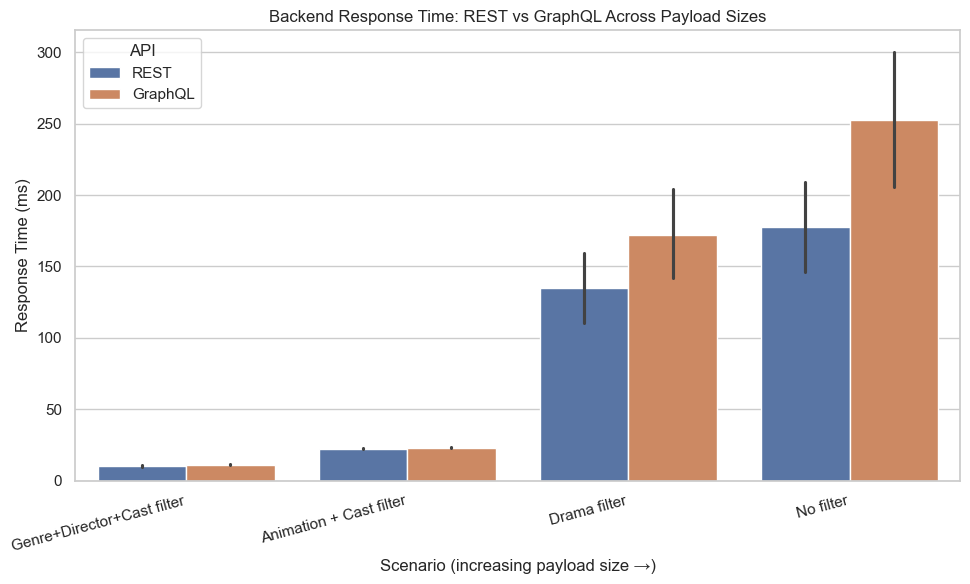

In [29]:
scenario_order = ["Genre+Director+Cast filter", "Animation + Cast filter", "Drama filter", "No filter"]
scenario_order = [s for s in scenario_order if s in clean_backend_df["Scenario"].unique()]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseTime(ms)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=("ci", 95), ax=ax,
)
ax.set_title("Backend Response Time: REST vs GraphQL Across Payload Sizes")
ax.set_ylabel("Response Time (ms)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_time_by_scenario.png", dpi=200)
plt.show()

### Response size (data transfer) by configuration and scenario

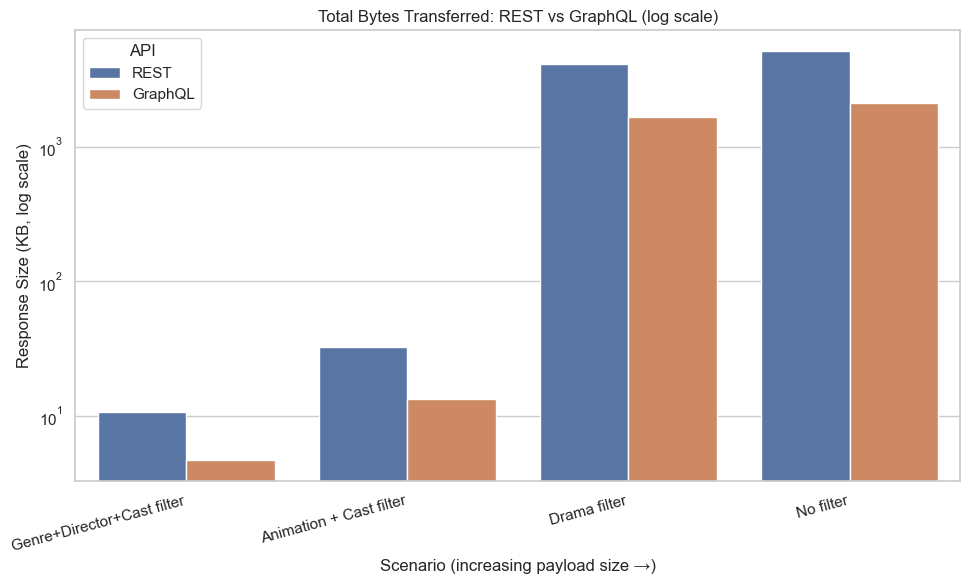

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
clean_backend_df["ResponseSize(KB)"] = clean_backend_df["ResponseSize(Bytes)"] / 1024
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseSize(KB)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=None, ax=ax,
)
ax.set_yscale("log")
ax.set_title("Total Bytes Transferred: REST vs GraphQL (log scale)")
ax.set_ylabel("Response Size (KB, log scale)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_size_by_scenario.png", dpi=200)
plt.show()

### FCP and LCP by loading strategy (primary scenario)

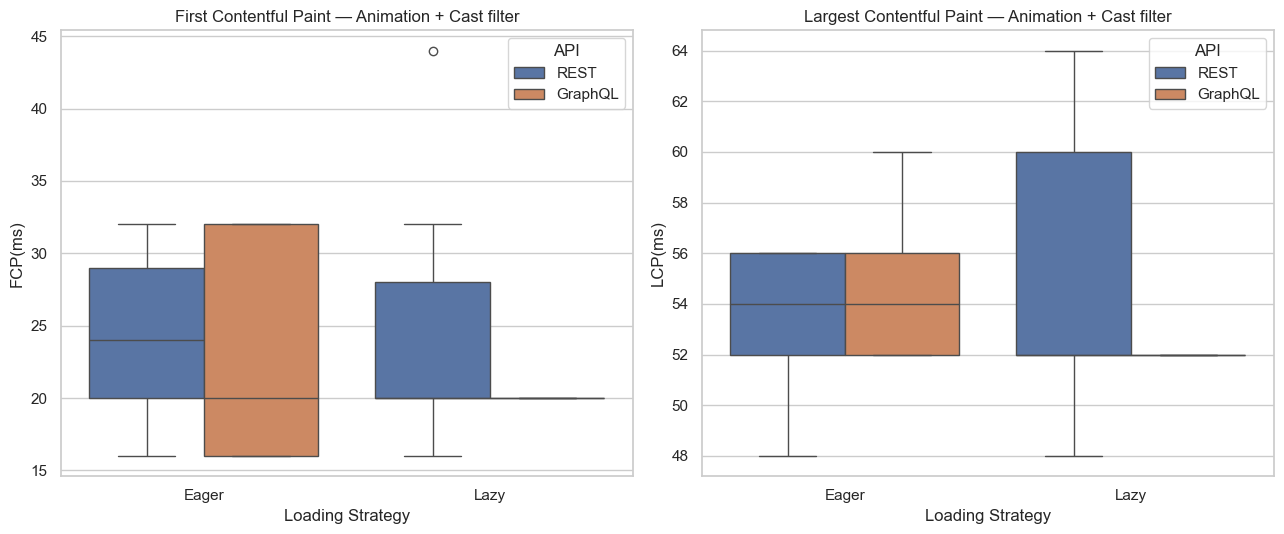

In [31]:
primary_frontend = clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, metric, title in zip(
    axes, ["FCP(ms)", "LCP(ms)"],
    ["First Contentful Paint", "Largest Contentful Paint"],
):
    sns.boxplot(
        data=primary_frontend, x="LoadingType", y=metric, hue="API",
        palette=PALETTE, ax=ax,
    )
    ax.set_title(f"{title} — {PRIMARY_SCENARIO}")
    ax.set_xlabel("Loading Strategy")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fcp_lcp_boxplots_primary.png", dpi=200)
plt.show()

### LCP across all four scenarios — testing the Eager/Lazy gap under different payloads

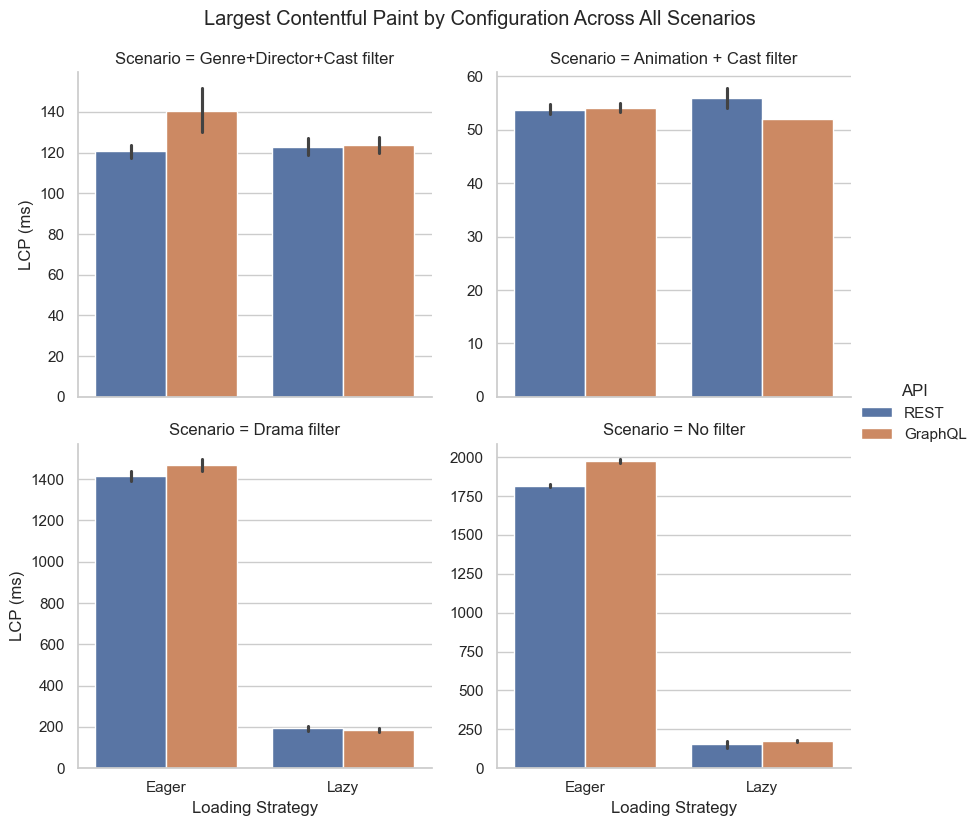

In [32]:
g = sns.catplot(
    data=clean_frontend_df, x="LoadingType", y="LCP(ms)", hue="API",
    col="Scenario", col_order=scenario_order, col_wrap=2,
    kind="bar", palette=PALETTE, errorbar=("ci", 95), height=4, aspect=1.1,
    sharey=False,
)
g.fig.suptitle("Largest Contentful Paint by Configuration Across All Scenarios", y=1.03)
g.set_axis_labels("Loading Strategy", "LCP (ms)")
g.savefig(f"{FIG_DIR}/lcp_all_scenarios.png", dpi=200)
plt.show()

### The 2×2 quadrant summary

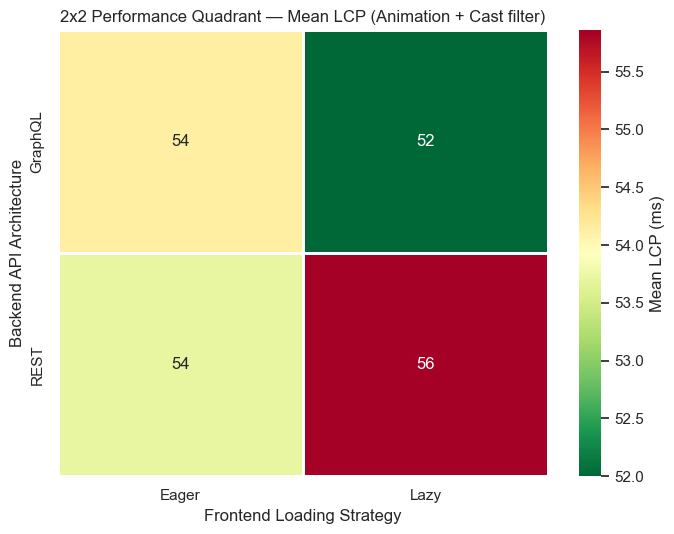

In [33]:
quadrant = (
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["LCP(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "Mean LCP (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2x2 Performance Quadrant — Mean LCP ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_lcp.png", dpi=200)
plt.show()

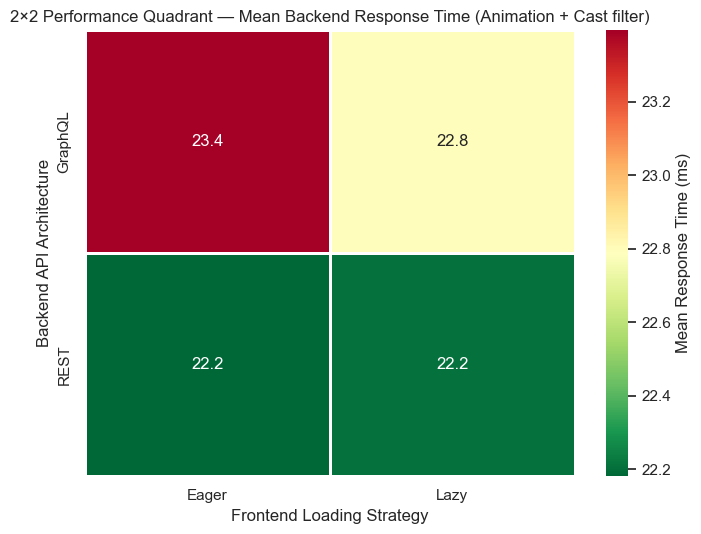

In [34]:
quadrant_rt = (
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["ResponseTime(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant_rt, annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "Mean Response Time (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2×2 Performance Quadrant — Mean Backend Response Time ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_responsetime.png", dpi=200)
plt.show()